# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV22"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv22')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv22/lv22-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV22,gene_band
0,PLIN1,6.626952,15q26.1
1,LEP,6.223140,7q32.1
2,SEMA3G,5.941609,3p21.1
3,LIPE,5.928367,19q13.2
4,BTNL9,5.747405,5q35.3
5,CD36,5.593815,7q21.11
6,GPD1,5.133220,12q13.12
7,LPL,4.301912,8p21.3
8,FZD4,4.265345,11q14.2
9,RBP7,4.005188,1p36.22


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 15:43:17,560 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 15:43:17,560 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR
122,KEGG_PPAR_SIGNALING_PATHWAY,22,0.791673,0.000145,0.001517


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP042620, SRP053101, SRP055749, SRP042086, SRP060355, SRP037778, SRP029899, SRP021478, SRP007338, SRP055512, SRP042186, SRP045545, SRP044756, SRP051211, SRP036821, SRP006575, SRP008218, SRP019936, SRP057196, SRP025982, SRP058722, SRP023262, SRP041538, SRP050499, SRP015013, SRP021193, SRP055569, SRP018359, SRP012461, SRP004965, SRP017575, SRP056041, SRP049449, 

In [12]:
lv_data.shape

(4793, 55)

In [13]:
lv_data.head()

tissue time type of surgical procedure  \
project   run                                                                   
SRP042620 SRR1313062  Breast Cancer Cell Line  NaN                        NaN   
          SRR1313063  Breast Cancer Cell Line  NaN                        NaN   
          SRR1313064  Breast Cancer Cell Line  NaN                        NaN   
          SRR1313065  Breast Cancer Cell Line  NaN                        NaN   
          SRR1313066  Breast Cancer Cell Line  NaN                        NaN   

                     phenotype patient #  age gender grouping disease state  \
project   run                                                                 
SRP042620 SRR1313062       NaN       NaN  NaN    NaN      NaN           NaN   
          SRR1313063       NaN       NaN  NaN    NaN      NaN           NaN   
          SRR1313064       NaN       NaN  NaN    NaN      NaN           NaN   
          SRR1313065       NaN       NaN  NaN    NaN      NaN           NaN   
          SRR1313066       NaN       NaN  NaN    NaN      NaN           NaN   

                     treatment  ... passages  day patient code name  \
project   run                   ...                                   
SRP042620 SRR1313062       NaN  ...      NaN  NaN               NaN   
          SRR1313063       NaN  ...      NaN  NaN               NaN   
          SRR1313064       NaN  ...      NaN  NaN               NaN   
          SRR1313065       NaN  ...      NaN  NaN               NaN   
          SRR1313066       NaN  ...      NaN  NaN               NaN   

                     cell marker antibody vender antibody catalog #  \
project   run                                                         
SRP042620 SRR1313062         NaN             NaN                NaN   
          SRR1313063         NaN             NaN                NaN   
          SRR1313064         NaN             NaN                NaN   
          SRR1313065         NaN             NaN                NaN   
          SRR1313066         NaN             NaN                NaN   

                     stromal signature prognosis mouse strain      LV22  
project   run                                                            
SRP042620 SRR1313062               NaN       NaN          NaN -0.059094  
          SRR1313063               NaN       NaN          NaN -0.029667  
          SRR1313064               NaN       NaN          NaN -0.056013  
          SRR1313065               NaN       NaN          NaN -0.052998  
          SRR1313066               NaN       NaN          NaN -0.033623  

[5 rows x 55 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

subject                       0.290599
time                          0.270243
time point                    0.254175
sample type                   0.147999
individual                    0.147999
read length                   0.118216
library type                  0.118216
tissue                        0.117968
grouping                      0.111440
gender                        0.090239
treatment                     0.079033
age                           0.064113
disease state                 0.057190
cell line                     0.038993
multiplex                     0.037366
librarybatch                  0.037366
replicate                     0.037366
type of surgical procedure    0.019662
passages                      0.017849
cell marker                   0.017464
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue            0.117968
cell line         0.038993
tissue subtype    0.008987
cell type         0.007381
tissue type       0.006557
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [17]:
lv_attrs_selected = [
    "tissue",
    "cell line",
    "tissue subtype",
    "cell type",
    "tissue type",
]

In [18]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [19]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [20]:
_tmp_seq[0]

tissue  \
project   run                                                             
SRP042620 SRR1313190  Uninvolved Breast Tissue Adjacent to ER+ Prima...   
          SRR1313177  Uninvolved Breast Tissue Adjacent to ER+ Prima...   
SRP053101 SRR1785283                                                NaN   
          SRR1785282                                                NaN   
SRP042620 SRR1313213  Uninvolved Breast Tissue Adjacent to TNBC Prim...   
SRP053101 SRR1785308                                                NaN   
          SRR1785309                                                NaN   
          SRR1785320                                                NaN   
          SRR1785321                                                NaN   
          SRR1785252                                                NaN   
          SRR1785253                                                NaN   
          SRR1785301                                                NaN   
          SRR1785300                                                NaN   
SRP042620 SRR1313222  Uninvolved Breast Tissue Adjacent to TNBC Prim...   
SRP055749 SRR1823870                                            Adipose   
SRP053101 SRR1785268                                                NaN   
          SRR1785279                                                NaN   
          SRR1785296                                                NaN   
          SRR1785297                                                NaN   
          SRR1785269                                                NaN   
SRP055749 SRR1823867                                            Adipose   
SRP042086 SRR1292160                                            adipose   
SRP053101 SRR1785278                                                NaN   
          SRR1785260                                                NaN   
          SRR1785261                                                NaN   

                     cell line tissue subtype cell type tissue type      LV22  
project   run                                                                  
SRP042620 SRR1313190       NaN            NaN       NaN         NaN  1.929598  
          SRR1313177       NaN            NaN       NaN         NaN  1.868060  
SRP053101 SRR1785283       NaN            NaN       NaN         NaN  1.728723  
          SRR1785282       NaN            NaN       NaN         NaN  1.728362  
SRP042620 SRR1313213       NaN            NaN       NaN         NaN  1.689730  
SRP053101 SRR1785308       NaN            NaN       NaN         NaN  1.660168  
          SRR1785309       NaN            NaN       NaN         NaN  1.659562  
          SRR1785320       NaN            NaN       NaN         NaN  1.648508  
          SRR1785321       NaN            NaN       NaN         NaN  1.646675  
          SRR1785252       NaN            NaN       NaN         NaN  1.630923  
          SRR1785253       NaN            NaN       NaN         NaN  1.628555  
          SRR1785301       NaN            NaN       NaN         NaN  1.622878  
          SRR1785300       NaN            NaN       NaN         NaN  1.618933  
SRP042620 SRR1313222       NaN            NaN       NaN         NaN  1.611920  
SRP055749 SRR1823870       NaN            NaN       NaN         NaN  1.610206  
SRP053101 SRR1785268       NaN            NaN       NaN         NaN  1.607203  
          SRR1785279       NaN            NaN       NaN         NaN  1.605536  
          SRR1785296       NaN            NaN       NaN         NaN  1.604754  
          SRR1785297       NaN            NaN       NaN         NaN  1.604311  
          SRR1785269       NaN            NaN       NaN         NaN  1.600574  
SRP055749 SRR1823867       NaN            NaN       NaN         NaN  1.593708  
SRP042086 SRR1292160       NaN            NaN       NaN         NaN  1.593473  
SRP053101 SRR1785278       NaN            NaN       NaN         NaN  1.591911  
          SRR1785260       NaN         

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [21]:
_tmp_seq[1]

tissue cell line tissue subtype cell type tissue type  \
project   run                                                                  
SRP053101 SRR1785247      NaN       NaN            NaN       NaN         NaN   
          SRR1785250      NaN       NaN            NaN       NaN         NaN   
          SRR1785273      NaN       NaN            NaN       NaN         NaN   
          SRR1785272      NaN       NaN            NaN       NaN         NaN   
          SRR1785251      NaN       NaN            NaN       NaN         NaN   
          SRR1785246      NaN       NaN            NaN       NaN         NaN   
          SRR1785317      NaN       NaN            NaN       NaN         NaN   
          SRR1785316      NaN       NaN            NaN       NaN         NaN   
SRP055749 SRR1823868  Adipose       NaN            NaN       NaN         NaN   
SRP053101 SRR1785294      NaN       NaN            NaN       NaN         NaN   
          SRR1785258      NaN       NaN            NaN       NaN         NaN   
          SRR1785259      NaN       NaN            NaN       NaN         NaN   
SRP042086 SRR1292165  adipose       NaN            NaN       NaN         NaN   
SRP053101 SRR1785295      NaN       NaN            NaN       NaN         NaN   
          SRR1785262      NaN       NaN            NaN       NaN         NaN   
          SRR1785263      NaN       NaN            NaN       NaN         NaN   
          SRR1785257      NaN       NaN            NaN       NaN         NaN   
          SRR1785256      NaN       NaN            NaN       NaN         NaN   
          SRR1785323      NaN       NaN            NaN       NaN         NaN   
          SRR1785322      NaN       NaN            NaN       NaN         NaN   
          SRR1785241      NaN       NaN            NaN       NaN         NaN   
SRP042086 SRR1292167  adipose       NaN            NaN       NaN         NaN   
SRP053101 SRR1785286      NaN       NaN            NaN       NaN         NaN   
          SRR1785240      NaN       NaN            NaN       NaN         NaN   
          SRR1785287      NaN       NaN            NaN       NaN         NaN   

                          LV22  
project   run                   
SRP053101 SRR1785247  1.568545  
          SRR1785250  1.565341  
          SRR1785273  1.565316  
          SRR1785272  1.563528  
          SRR1785251  1.561876  
          SRR1785246  1.561756  
          SRR1785317  1.558813  
          SRR1785316  1.555573  
SRP055749 SRR1823868  1.554512  
SRP053101 SRR1785294  1.552146  
          SRR1785258  1.551335  
          SRR1785259  1.551058  
SRP042086 SRR1292165  1.548738  
SRP053101 SRR1785295  1.548129  
          SRR1785262  1.535908  
          SRR1785263  1.535659  
          SRR1785257  1.534057  
          SRR1785256  1.531624  
          SRR1785323  1.527743  
          SRR1785322  1.520904  
          SRR1785241  1.515723  
SRP042086 SRR1292167  1.514340  
SRP053101 SRR1785286  1.513603  
          SRR1785240  1.512265  
          SRR1785287  1.509888

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [24]:
# list the top 10 samples from this project
lv_data.loc[["SRP053101"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

time  type of surgical procedure      LV22
project   run                                                  
SRP053101 SRR1785283   T3  adjustable gastric banding  1.728723
          SRR1785282   T3  adjustable gastric banding  1.728362
          SRR1785308   T3    Roux-en-Y gastric bypass  1.660168
          SRR1785309   T3    Roux-en-Y gastric bypass  1.659562
          SRR1785320   T3  adjustable gastric banding  1.648508
          SRR1785321   T3  adjustable gastric banding  1.646675
          SRR1785252   T0    Roux-en-Y gastric bypass  1.630923
          SRR1785253   T0    Roux-en-Y gastric bypass  1.628555
          SRR1785301   T3    Roux-en-Y gastric bypass  1.622878
          SRR1785300   T3    Roux-en-Y gastric bypass  1.618933

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP053101
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [26]:
SELECTED_ATTRIBUTES = [
    "tissue",
    "cell line",
    "tissue subtype",
    "cell type",
    "tissue type",
]

## Get a single attribute with "cell type/tissue" information

In [27]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [28]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [29]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [30]:
plot_data.head(20)

tissue  \
project   run                                                             
SRP042620 SRR1313190  Uninvolved Breast Tissue Adjacent to ER+ Prima...   
          SRR1313177  Uninvolved Breast Tissue Adjacent to ER+ Prima...   
SRP053101 SRR1785283                                    NOT CATEGORIZED   
          SRR1785282                                    NOT CATEGORIZED   
SRP042620 SRR1313213  Uninvolved Breast Tissue Adjacent to TNBC Prim...   
SRP053101 SRR1785308                                    NOT CATEGORIZED   
          SRR1785309                                    NOT CATEGORIZED   
          SRR1785320                                    NOT CATEGORIZED   
          SRR1785321                                    NOT CATEGORIZED   
          SRR1785252                                    NOT CATEGORIZED   
          SRR1785253                                    NOT CATEGORIZED   
          SRR1785301                                    NOT CATEGORIZED   
          SRR1785300                                    NOT CATEGORIZED   
SRP042620 SRR1313222  Uninvolved Breast Tissue Adjacent to TNBC Prim...   
SRP055749 SRR1823870                                            Adipose   
SRP053101 SRR1785268                                    NOT CATEGORIZED   
          SRR1785279                                    NOT CATEGORIZED   
          SRR1785296                                    NOT CATEGORIZED   
          SRR1785297                                    NOT CATEGORIZED   
          SRR1785269                                    NOT CATEGORIZED   

                          LV22  
project   run                   
SRP042620 SRR1313190  1.929598  
          SRR1313177  1.868060  
SRP053101 SRR1785283  1.728723  
          SRR1785282  1.728362  
SRP042620 SRR1313213  1.689730  
SRP053101 SRR1785308  1.660168  
          SRR1785309  1.659562  
          SRR1785320  1.648508  
          SRR1785321  1.646675  
          SRR1785252  1.630923  
          SRR1785253  1.628555  
          SRR1785301  1.622878  
          SRR1785300  1.618933  
SRP042620 SRR1313222  1.611920  
SRP055749 SRR1823870  1.610206  
SRP053101 SRR1785268  1.607203  
          SRR1785279  1.605536  
          SRR1785296  1.604754  
          SRR1785297  1.604311  
          SRR1785269  1.600574

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [31]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [32]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [33]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [34]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [35]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [36]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [37]:
N_TOP_ATTRS = 10

In [38]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [39]:
len(attr_order)

10

In [40]:
attr_order[:5]

['Uninvolved Breast Tissue Adjacent to ER+ Primary Tumor',
 'NOT CATEGORIZED',
 'Uninvolved Breast Tissue Adjacent to TNBC Primary Tumor',
 'Adipose',
 'adipose']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

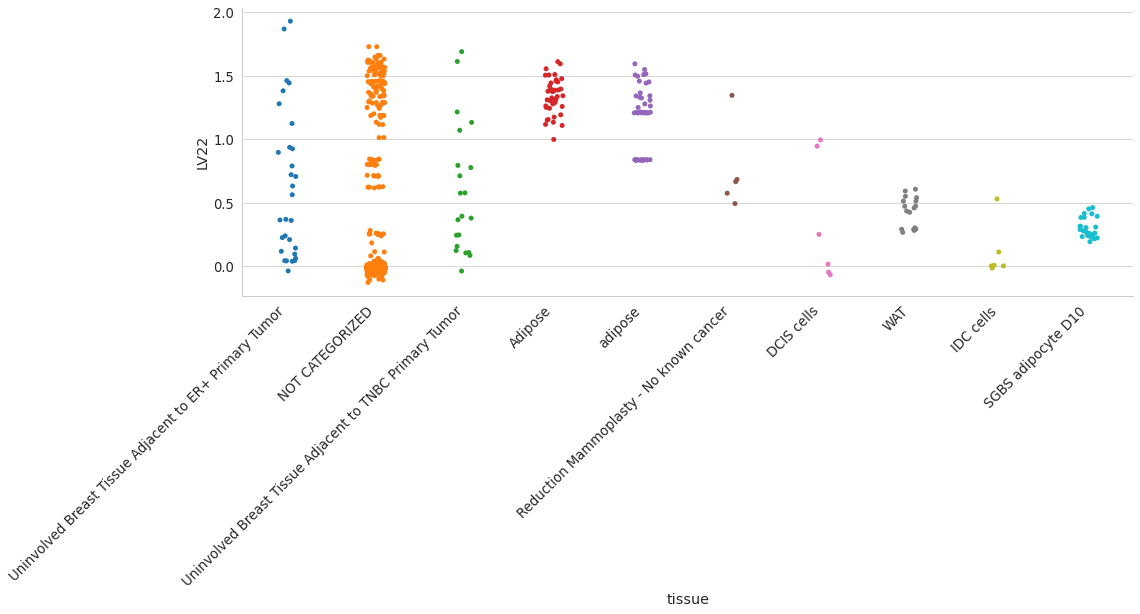

In [41]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [42]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("NOT CAT")
    ]
    display(_tmp.head(20))

tissue      LV22
project   run                                  
SRP053101 SRR1785283  NOT CATEGORIZED  1.728723
          SRR1785282  NOT CATEGORIZED  1.728362
          SRR1785308  NOT CATEGORIZED  1.660168
          SRR1785309  NOT CATEGORIZED  1.659562
          SRR1785320  NOT CATEGORIZED  1.648508
          SRR1785321  NOT CATEGORIZED  1.646675
          SRR1785252  NOT CATEGORIZED  1.630923
          SRR1785253  NOT CATEGORIZED  1.628555
          SRR1785301  NOT CATEGORIZED  1.622878
          SRR1785300  NOT CATEGORIZED  1.618933
          SRR1785268  NOT CATEGORIZED  1.607203
          SRR1785279  NOT CATEGORIZED  1.605536
          SRR1785296  NOT CATEGORIZED  1.604754
          SRR1785297  NOT CATEGORIZED  1.604311
          SRR1785269  NOT CATEGORIZED  1.600574
          SRR1785278  NOT CATEGORIZED  1.591911
          SRR1785260  NOT CATEGORIZED  1.580438
          SRR1785261  NOT CATEGORIZED  1.576488
          SRR1785247  NOT CATEGORIZED  1.568545
          SRR1785250  NOT CATEGORIZED  1.565341

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP053101, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [43]:
# what is there in these projects?
lv_data.loc[["SRP053101"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

time  type of surgical procedure      LV22
project   run                                                  
SRP053101 SRR1785283   T3  adjustable gastric banding  1.728723
          SRR1785282   T3  adjustable gastric banding  1.728362
          SRR1785308   T3    Roux-en-Y gastric bypass  1.660168
          SRR1785309   T3    Roux-en-Y gastric bypass  1.659562
          SRR1785320   T3  adjustable gastric banding  1.648508
          SRR1785321   T3  adjustable gastric banding  1.646675
          SRR1785252   T0    Roux-en-Y gastric bypass  1.630923
          SRR1785253   T0    Roux-en-Y gastric bypass  1.628555
          SRR1785301   T3    Roux-en-Y gastric bypass  1.622878
          SRR1785300   T3    Roux-en-Y gastric bypass  1.618933
          SRR1785268   T0  adjustable gastric banding  1.607203
          SRR1785279   T0  adjustable gastric banding  1.605536
          SRR1785296   T3    Roux-en-Y gastric bypass  1.604754
          SRR1785297   T3    Roux-en-Y gastric bypass  1.604311
          SRR1785269   T0  adjustable gastric banding  1.600574
          SRR1785278   T0  adjustable gastric banding  1.591911
          SRR1785260   T0    Roux-en-Y gastric bypass  1.580438
          SRR1785261   T0    Roux-en-Y gastric bypass  1.576488
          SRR1785247   T0    Roux-en-Y gastric bypass  1.568545
          SRR1785250   T0    Roux-en-Y gastric bypass  1.565341
          SRR1785273   T0  adjustable gastric banding  1.565316
          SRR1785272   T0  adjustable gastric banding  1.563528
          SRR1785251   T0    Roux-en-Y gastric bypass  1.561876
          SRR1785246   T0    Roux-en-Y gastric bypass  1.561756
          SRR1785317   T3  adjustable gastric banding  1.558813
          SRR1785316   T3  adjustable gastric banding  1.555573
          SRR1785294   T3    Roux-en-Y gastric bypass  1.552146
          SRR1785258   T0    Roux-en-Y gastric bypass  1.551335
          SRR1785259   T0    Roux-en-Y gastric bypass  1.551058
          SRR1785295   T3    Roux-en-Y gastric bypass  1.548129
          SRR1785262   T0  adjustable gastric banding  1.535908
          SRR1785263   T0  adjustable gastric banding  1.535659
          SRR1785257   T0    Roux-en-Y gastric bypass  1.534057
          SRR1785256   T0    Roux-en-Y gastric bypass  1.531624
          SRR1785323   T3  adjustable gastric banding  1.527743
          SRR1785322   T3  adjustable gastric banding  1.520904
          SRR1785241   T0    Roux-en-Y gastric bypass  1.515723
          SRR1785286   T3    Roux-en-Y gastric bypass  1.513603
          SRR1785240   T0    Roux-en-Y gastric bypass  1.512265
          SRR1785287   T3    Roux-en-Y gastric bypass  1.509888
          SRR1785275   T0    Roux-en-Y gastric bypass  1.506728
          SRR1785274   T0    Roux-en-Y gastric bypass  1.502209
          SRR1785255   T0  adjustable gastric banding  1.500992
          SRR1785291   T3    Roux-en-Y gastric bypass  1.500644
          SRR1785290   T3    Roux-en-Y gastric bypass  1.500367
          SRR1785254   T0  adjustable gastric banding  1.497254
          SRR1785288   T3    Roux-en-Y gastric bypass  1.460749
          SRR1785289   T3    Roux-en-Y gastric bypass  1.458179
          SRR1785298   T3  adjustable gastric banding  1.456336
          SRR1785302   T3    Roux-en-Y gastric bypass  1.455050
          SRR1785299   T3  adjustable gastric banding  1.454313
          SRR1785312   T3  adjustable gastric banding  1.453186
          SRR1785303   T3    Roux-en-Y gastric bypass  1.452317
          SRR1785313   T3  adjustable gastric banding  1.450389
          SRR1785265   T0    Roux-en-Y gastric bypass  1.444024
          SRR1785264   T0    Roux-en-Y gastric bypass  1.441948
          SRR1785284   T3    Roux-en-Y gastric bypass  1.439642
          SRR1785285   T3    Roux-en-Y gastric bypass  1.439158
          SRR1785243   T0    Roux-en-Y gastric bypass  1.436153
          SRR1785242   T0    Roux-en-Y gastric bypass  1.434383

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.